In [ ]:
import numpy as np
import matplotlib.pyplot as plot
from plant.parameters import params
from scipy.interpolate import RegularGridInterpolator

#### 1.1 Formulate optimization problem

**Objective**
$$
\min \quad J = \sum_{k=0}^{N-1} \dot{m}(k) \, \Delta t
\qquad \text{where} \qquad
\dot{m}(k) = \frac{P_{ICE}(k) + P_{ICE,0}}{\eta_{ICE} \, H_{lhv}}
$$

**State dynamics**
$$
\begin{aligned}
SoC(k+1) &= SoC(k) - \frac{\Delta t}{Q_{bat} V_{oc}} \, P_{MGU\text{-}K}(k) \\[6pt]
E_{ES2K}(k+1) &= E_{ES2K}(k) + \max\big(P_{MGU\text{-}K}(k), \, 0\big) \, \Delta t
\end{aligned}
$$

**Power balance** (regime dependent, the ICE cannot absorb negative power; excess braking power is dissipated by the mechanical brakes, at no fuel or energy cost)
$$
P_{gb}(k) =
\begin{cases}
P_{ICE}(k) + P_{MGU\text{-}K}(k), & P_{gb}(k) \ge 0 \quad \text{(traction)}\\[4pt]
P_{MGU\text{-}K}(k) + P_{brake}(k), & P_{gb}(k) < 0 \quad \text{(braking)}
\end{cases}
$$

**Control bounds** single decision variable $P_{MGU\text{-}K}(k)$; $P_{ICE}(k)$ and $P_{brake}(k)$ follow from the power balance above.

$$
\begin{cases}
P_{gb}(k) - P_{ICE}^{max} \;\le\; P_{MGU\text{-}K}(k) \;\le\; P_{gb}(k), & P_{gb}(k) \ge 0\\[8pt]
P_{gb}(k) \;\le\; P_{MGU\text{-}K}(k) \;\le\; 0, & P_{gb}(k) < 0
\end{cases}
$$

together with, at every $k$:
$$
\begin{aligned}
P_{MGU\text{-}K}^{min} \;\le\;& P_{MGU\text{-}K}(k) \;\le\; P_{MGU\text{-}K}^{max} \\[6pt]
\frac{(SoC^{max} - SoC(k))\,Q_{bat}V_{oc}}{-\Delta t} \;\le\;& P_{MGU\text{-}K}(k) \;\le\; \frac{(SoC^{min} - SoC(k))\,Q_{bat}V_{oc}}{-\Delta t} \\[6pt]
P_{MGU\text{-}K}(k) \;\le\;& \frac{E_{ES2K}^{max} - E_{ES2K}(k)}{\Delta t}
\end{aligned}
$$

**Component and regulatory limits**
$$
\begin{aligned}
0 &\le P_{ICE}(k) \le P_{ICE}^{max} \\
P_{brake}(k) &\le 0 \\
0 &\le \dot{m}(k) \le \dot{m}^{max} = 75 \ \text{kg/h} \\
0 &\le E_{ES2K}(k) \le E_{ES2K}^{max} = 9 \ \text{MJ}
\end{aligned}
$$

In [ ]:
#Define the parameters
Delta_t = 0.1

# Fuel consumption in grams per unit energy

Voc = params['V_oc_nom'] 
Q_bat = params['E_pack_capacity'] / Voc

# Limits on Batt Power, Eng Power, SOC
P_MGU_max = params['P_MGU_max']  # 350[kW]
P_MGU_min = params['P_MGU_min']  # -200[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SOC_min = params['SoC_min']     # 0.1[-]
SOC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']

# Load Data: of t,v,a
data = np.load('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/Spanish_qualifying.npy')

t = data[0,:]
v = data[1,:]
a = data[2,:]

# Load Data: power at the gearbox
data_of_power_gb = np.load('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/power_domand.npy')
P_gb = data_of_power_gb[1,:]



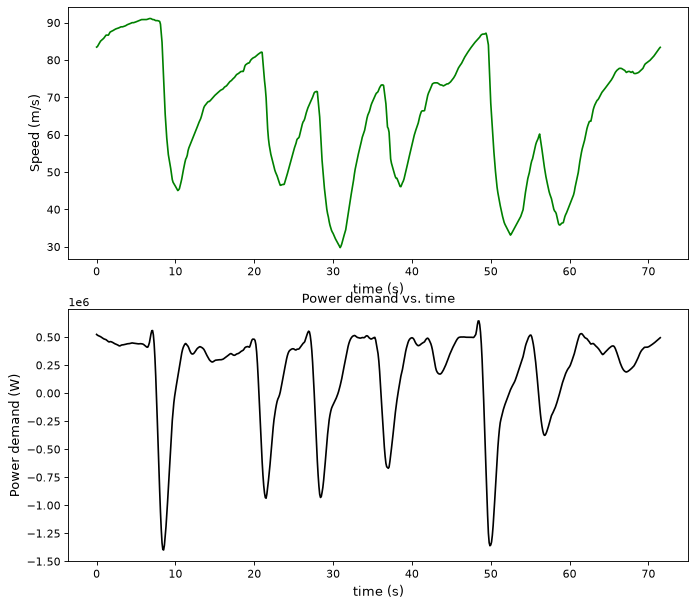

In [ ]:
plot.figure(num=1, figsize=(10, 9), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(2,1,1)
plot.plot(t,v,'g')
plot.ylabel('Speed (m/s)', fontsize= 12)
plot.xlabel('time (s)', fontsize= 12)

plot.subplot(2,1,2)
plot.plot(t, P_gb, 'k')
plot.xlabel('time (s)', fontsize=12)
plot.ylabel('Power demand (W)', fontsize=12)
plot.title('Power demand vs. time', fontsize=12)
plot.show()

In [ ]:
SoC_grid = np.linspace(SOC_min,SOC_max, 100)
E_ES2K_grid = np.linspace(0, E_ES2K_max, 100)

#Grid size
ns = len(SoC_grid) # No. of states
ne = len(E_ES2K_grid)

# Planning horizon (time steps)
N = len(t)

# Preallocate Value Function (rows index state, columns index time)
V = np.inf*np.ones((ns,ne,N+1))


# Preallocate Control (rows index state, columns index time)
u_star = np.zeros((ns,ne, N))

In [ ]:
# Boundary Condition of Value Function (Principle of Optimality)
V[:,N] = 0

# Iterate backward in time
for k in range(N-1,-1,-1):
    # Iterate over SOC
    for i in range(0,ns):
        #Iterate over E_ES2K
        for j in range(0,ne):
            # Find dominant bounds for P_batt
            if P_gb[k]>=0:
                lb = max([(((SOC_max - SoC_grid[i]) * Q_bat * Voc) / -Delta_t), P_gb[k] - P_eng_max])
                ub = min([(((SOC_min - SoC_grid[i]) * Q_bat * Voc) / -Delta_t), P_MGU_max, P_gb[k], (E_ES2K_max-E_ES2K_grid[j])/Delta_t]) 
            else: 
                lb = max([(((SOC_max - SoC_grid[i]) * Q_bat * Voc) / -Delta_t), P_MGU_min, P_gb[k]])
                ub = min([(((SOC_min - SoC_grid[i]) * Q_bat * Voc) / -Delta_t), 0]) 

            # Grid Battery Power between dominant bounds
            P_mguk_grid = np.linspace(lb, ub, 200)

            # Compute engine power (vectorized for all P_batt_grid)
            if P_gb[k]>=0:
                P_eng = P_gb[k] - P_mguk_grid
            else:
                P_eng = np.zeros_like(P_mguk_grid)
            m_dot = (P_eng + P_ICE0) / (eta_ICE * LHV)
            m_dot = np.clip(m_dot, 0, params['m_dot_max']/3600)

            # Cost-per-time-step, a.k.a. fuel consumed at each stage (vectorized for all P_batt_grid)
            g_k = m_dot * Delta_t

            # compute next SOC using dynamics
            SoC_nxt = SoC_grid[i] - P_mguk_grid*Delta_t/(Q_bat * Voc)
            E_ES2K_next = E_ES2K_grid[j] + np.maximum(P_mguk_grid, 0)*Delta_t

            # Compute value function at nxt time step (need to interpolate)
            interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1],bounds_error=False, fill_value=None)   # fill_value=None = estrapola invece di dare NaN)
            points = np.column_stack([SoC_nxt, E_ES2K_next])
            V_nxt = interp_Vnext(points)

            # Value Function (Principle of Optimality)
            V[i,j,k] = min(g_k + V_nxt)
            ind = np.argmin(g_k + V_nxt)

            # Save Optimal Control
            u_star[i,j,k] = P_mguk_grid[ind]

